Desafio 11 Dígitos Mnist (Grupo 11)


---
Luca Casari Veloso de Almeida; RA: 2034961
Maria Luiza dos Santos; RA: 2037325



##Importação e Preparação do ambiente

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torchvision import transforms
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.datasets import make_classification, fetch_openml
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
np.random.seed(42)
print("Ambiente configurado!")

###Carregamento de dados

In [ ]:
mnist=fetch_openml('mnist_784',version=1,as_frame=False)
X=mnist.data.astype(np.float32)
y=mnist.target.astype(np.uint8)

In [ ]:
#alternativa
dataset=pd.read_csv("mnist_784.csv")
X=dataset.drop(columns=["class"]).astype(np.float32).values
y=dataset["class"].astype(np.uint8).values

##Análise exploratória de dados (EDA)

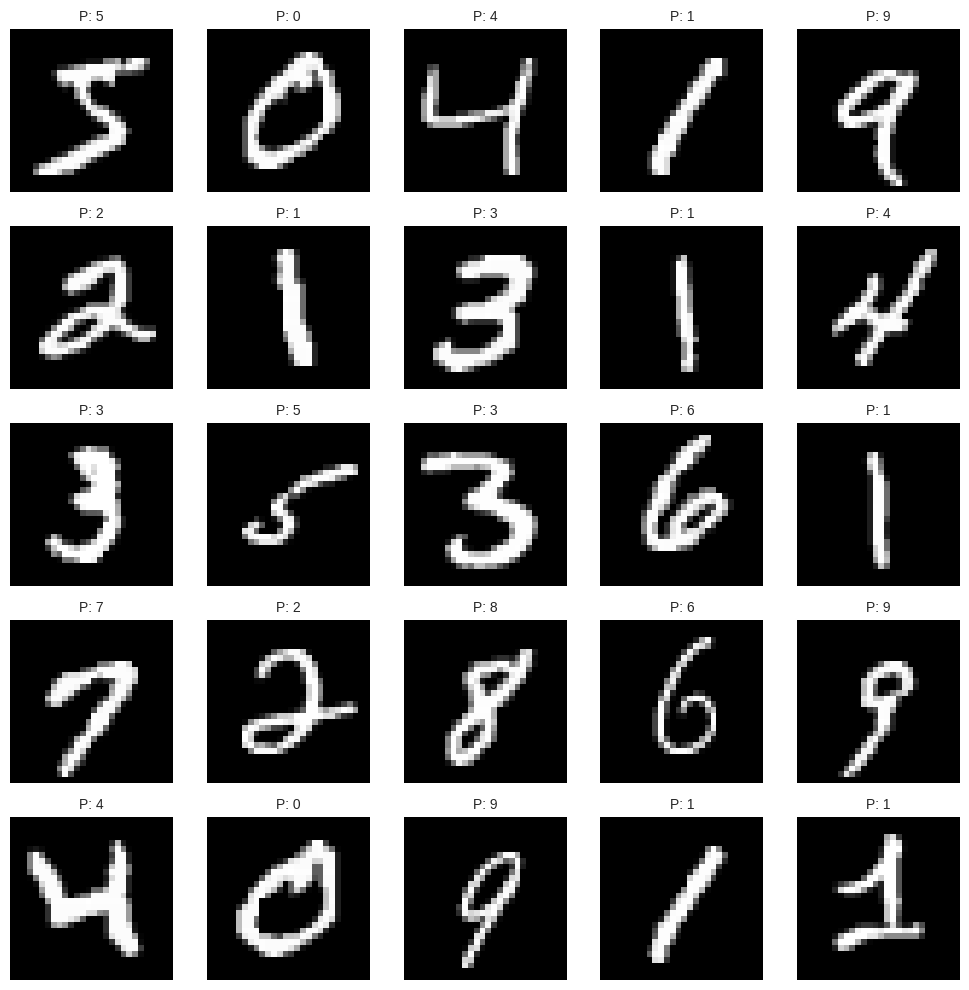

In [ ]:
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"P: {y[i]}", fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
numeros={'0':[],'1':[],'2':[],'3':[],'4':[],'5':[],'6':[],'7':[],'8':[],'9':[]}
for index,i in enumerate(y):
  numeros[f'{i}'].append([X[index],i])

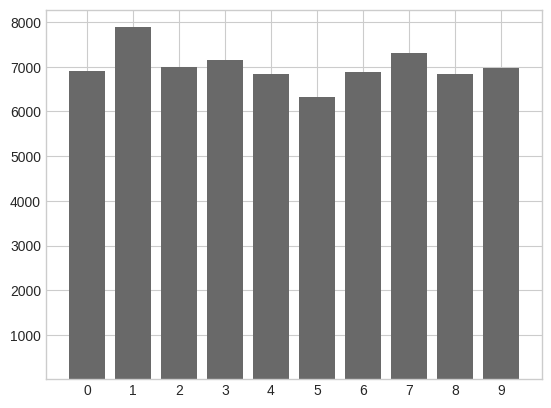

In [ ]:
digitos=[]
for i in range(10):
  digitos.append(len(numeros[f'{i}'[0]]))
plt.bar([0,1,2,3,4,5,6,7,8,9], digitos, color='dimgray',bottom=10)
plt.xticks([0,1,2,3,4,5,6,7,8,9])
plt.show()

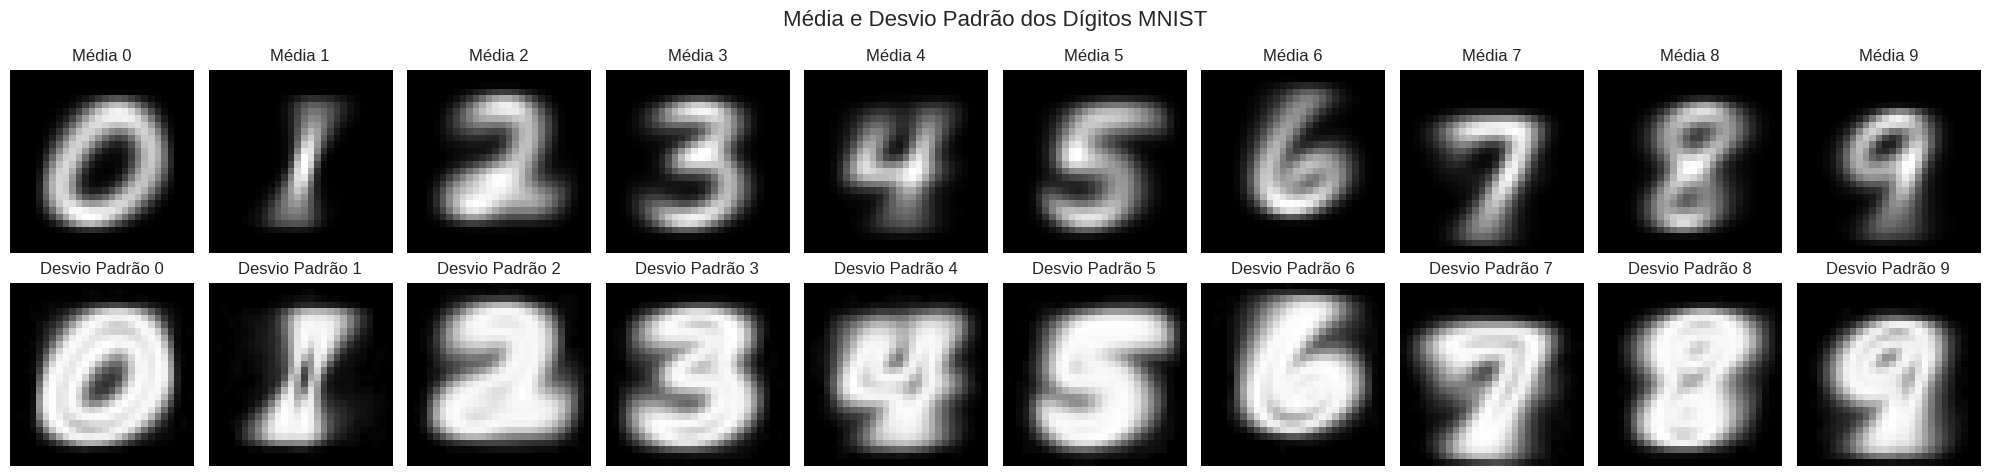

In [ ]:
media_digitos=[]
dp_digitos=[]

for digito in range(10):
    digito_images=np.array([item[0] for item in numeros[str(digito)]])
    media_imagem=np.mean(digito_images, axis=0)
    dp_imagem=np.std(digito_images, axis=0)
    media_digitos.append(media_imagem)
    dp_digitos.append(dp_imagem)
fig, axes=plt.subplots(2, 10, figsize=(20, 5))
fig.suptitle('Média e Desvio Padrão dos Dígitos MNIST', fontsize=16)

for i in range(10):
    axes[0, i].imshow(media_digitos[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_title(f'Média {i}')
    axes[0, i].axis('off')
    axes[1, i].imshow(dp_digitos[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title(f'Desvio Padrão {i}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

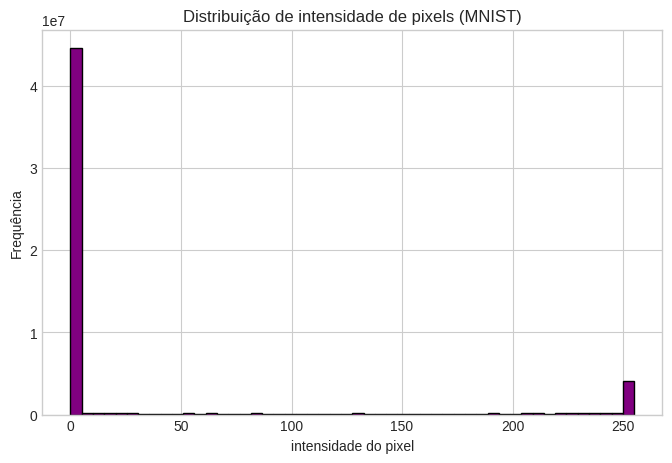

In [ ]:
pixels=X.flatten()
plt.figure(figsize=(8,5))
plt.hist(pixels,bins=50,color='purple',edgecolor='black')
plt.xlabel("intensidade do pixel")
plt.ylabel("Frequência")
plt.title("Distribuição de intensidade de pixels (MNIST)")
plt.show()

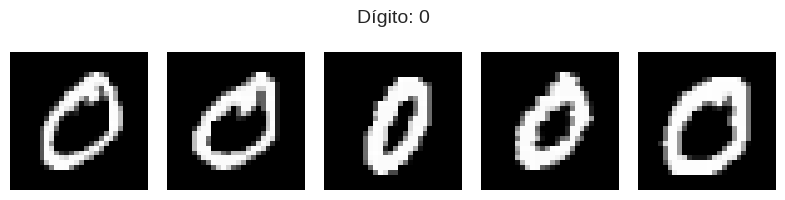

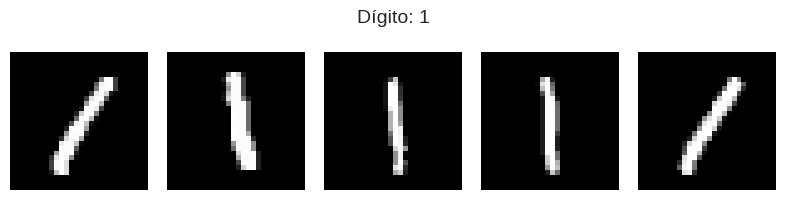

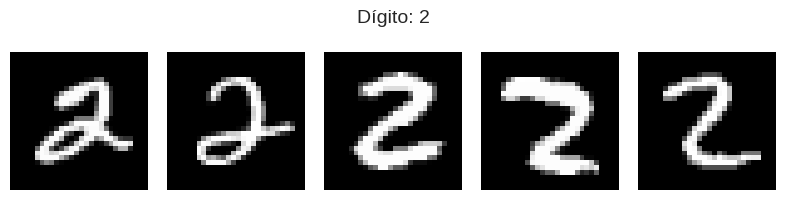

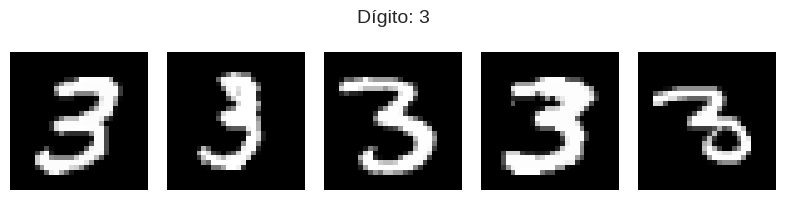

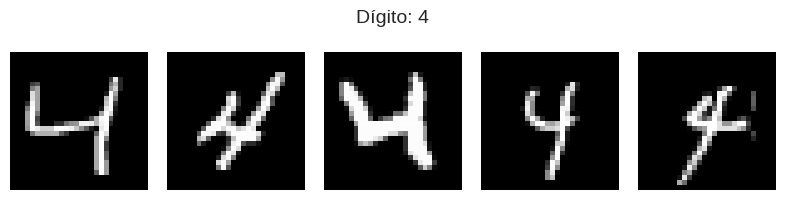

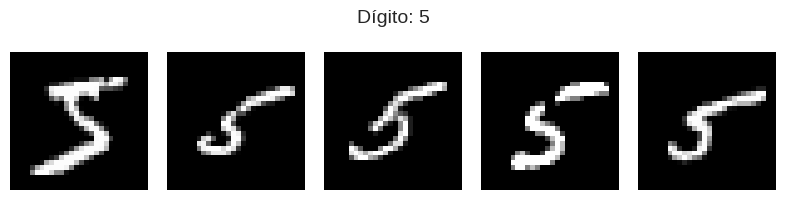

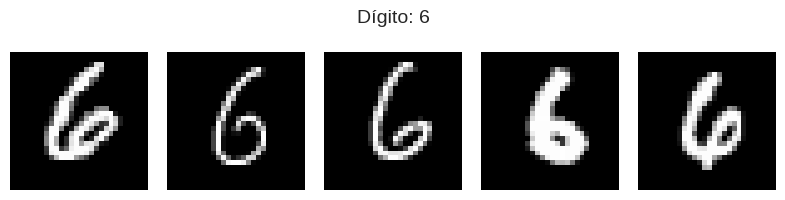

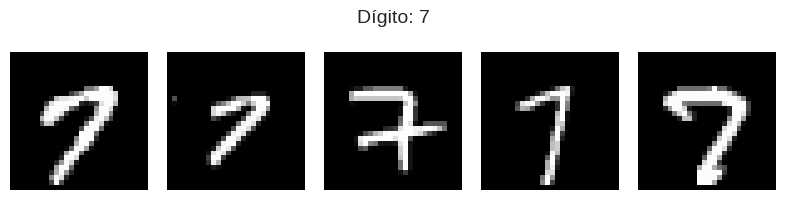

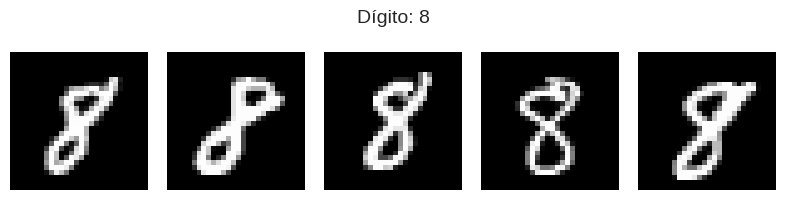

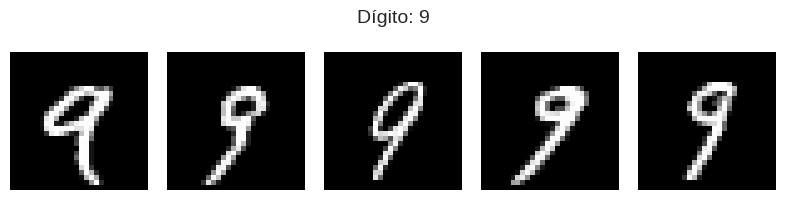

In [ ]:
for num in range(10):
  fig, axes = plt.subplots(1, 5, figsize=(8, 2))
  fig.suptitle(f'Dígito: {num}', fontsize=14)
  for i, ax in enumerate(axes.flat):
    ax.imshow(numeros[f'{num}'][i][0].reshape(28,28),cmap='gray')
    ax.axis('off')
  plt.tight_layout()
  plt.show()

##Pré-processamento

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
X_train,X_val,y_train,y_val=train_test_split(X_train,y_train,test_size=0.25,stratify=y_train,random_state=42)

In [ ]:
transform = transforms.ToTensor()
media=(0.5,)
dp=(0.5,)
nt=transforms.Normalize(media,dp)
for index,i in enumerate(X_train):
  im_tensor=transform(i.reshape(28, 28).astype(np.uint8))
  im_tensor=im_tensor.to(torch.float32)
  X_train[index]=nt(im_tensor).squeeze().numpy().flatten()
for index,i in enumerate(X_test):
  im_tensor=transform(i.reshape(28, 28).astype(np.uint8))
  im_tensor=im_tensor.to(torch.float32)
  X_test[index]=nt(im_tensor).squeeze().numpy().flatten()
for index,i in enumerate(X_val):
  im_tensor=transform(i.reshape(28, 28).astype(np.uint8))
  im_tensor=im_tensor.to(torch.float32)
  X_val[index]=nt(im_tensor).squeeze().numpy().flatten()

In [ ]:
pca=PCA(n_components=50)
X_train_pca=pca.fit_transform(X_train)
X_test_pca=pca.transform(X_test)
X_val_pca=pca.transform(X_val)

##Comparação de modelos

###KNN

In [ ]:
knn=KNeighborsClassifier()
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)
acc=accuracy_score(y_pred,y_test)
print(round(acc*100,2))

96.62


In [ ]:
knn_pca=KNeighborsClassifier()
knn_pca.fit(X_train_pca,y_train)
y_pred_pca=knn_pca.predict(X_test_pca)
acc=accuracy_score(y_pred_pca,y_test)
print(round(acc*100,2))

97.43


In [ ]:
knn = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn.fit(X_train_pca, y_train)
y_pred = knn.predict(X_test_pca)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9759285714285715
[[1373    1    1    0    0    0    4    0    1    1]
 [   0 1564    4    2    0    1    0    3    0    1]
 [   7    8 1352    3    1    1    4   18    4    0]
 [   0    1    7 1382    1   11    2   11    9    4]
 [   3    5    0    0 1314    0    4    3    2   34]
 [   5    1    1    6    0 1223   16    2    3    6]
 [   5    4    1    0    1    4 1359    0    1    0]
 [   1    8    3    0    1    0    0 1432    1   13]
 [   2    4    2   16    2   11    5    2 1312    9]
 [   2    6    0    8   10    2    0   10    1 1352]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1381
           1       0.98      0.99      0.98      1575
           2       0.99      0.97      0.98      1398
           3       0.98      0.97      0.97      1428
           4       0.99      0.96      0.98      1365
           5       0.98      0.97      0.97      1263
           6       0.97      0.99      0.98      1375
       

###Random Forest

In [ ]:
max_depths = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, None]

best_accuracy = 0
best_max_depth = None

results = []

for depth in max_depths:
    rf_tuned = RandomForestClassifier(max_depth=depth, random_state=42, n_jobs=-1)
    rf_tuned.fit(X_train, y_train)
    val_accuracy = rf_tuned.score(X_val, y_val)
    results.append({'max_depth': depth, 'validation_accuracy': val_accuracy})

    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_max_depth = depth

print("Resultados para valores de max_depth diferentes:")
for res in results:
    print(f"max_depth: {res['max_depth']}, Acurácia de Validação: {res['validation_accuracy']:.4f}")

print(f"\nMelhor max_depth: {best_max_depth}, com Acurácia de Validação: {best_accuracy:.4f}")

Resultados para valores de max_depth diferentes:
max_depth: 10, Acurácia de Validação: 0.9456
max_depth: 20, Acurácia de Validação: 0.9649
max_depth: 30, Acurácia de Validação: 0.9665
max_depth: 40, Acurácia de Validação: 0.9668
max_depth: 50, Acurácia de Validação: 0.9666
max_depth: 60, Acurácia de Validação: 0.9666
max_depth: 70, Acurácia de Validação: 0.9666
max_depth: 80, Acurácia de Validação: 0.9666
max_depth: 90, Acurácia de Validação: 0.9666
max_depth: 100, Acurácia de Validação: 0.9666
max_depth: None, Acurácia de Validação: 0.9666

Melhor max_depth: 40, com Acurácia de Validação: 0.9668


In [ ]:
rf = RandomForestClassifier(max_depth=40, random_state=42)
rf.fit(X_train, y_train)
print(rf.score(X_train, y_train))
print(rf.score(X_val, y_val))
print(rf.score(X_test, y_test))
y_pred_rf=rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

1.0
0.9667857142857142
0.9647142857142857
Accuracy: 0.9647142857142857
[[1368    1    1    0    1    1    3    0    5    1]
 [   0 1546    7    7    1    4    2    5    1    2]
 [   9    1 1342    6    6    1    6   13   13    1]
 [   2    1   19 1365    0   13    1   11   12    4]
 [   4    4    4    0 1305    0    7    1    3   37]
 [   4    1    5   22    1 1197   12    2   10    9]
 [   8    3    1    0    2    6 1350    0    5    0]
 [   3    6   12    0    7    1    0 1410    5   15]
 [   4    3    7   14    2    8    3    1 1305   18]
 [   7    8    1   15   15    3    2   10   12 1318]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1381
           1       0.98      0.98      0.98      1575
           2       0.96      0.96      0.96      1398
           3       0.96      0.96      0.96      1428
           4       0.97      0.96      0.96      1365
           5       0.97      0.95      0.96      1263
           6       

###Multi-layer Perceptron

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, activation='relu', solver='adam', random_state=42)
mlp.fit(X_train_pca, y_train)
y_pred_mlp = mlp.predict(X_test_pca)
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"MLP Accuracy: {accuracy_mlp:.4f}")
print(confusion_matrix(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

MLP Accuracy: 0.9756
[[1363    1    1    2    1    2    6    0    2    3]
 [   0 1559    6    2    1    1    1    5    0    0]
 [   3    2 1362    4    3    3    4    8    6    3]
 [   1    0   11 1387    0    9    1    4    7    8]
 [   2    4    2    0 1327    1    4    1    3   21]
 [   5    0    1    7    1 1227    7    2   10    3]
 [   8    2    1    1    4    4 1352    1    2    0]
 [   3    3    6    1    6    1    0 1426    1   12]
 [   6    2    4   15    0    1    8    2 1317   10]
 [   4    6    0    7    8    8    1   11    7 1339]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1381
           1       0.99      0.99      0.99      1575
           2       0.98      0.97      0.98      1398
           3       0.97      0.97      0.97      1428
           4       0.98      0.97      0.98      1365
           5       0.98      0.97      0.97      1263
           6       0.98      0.98      0.98      1375
           7   

In [ ]:
print("\n--- KNN Classification Report ---")
print(classification_report(y_test, y_pred))

print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))

print("\n--- MLP Classification Report ---")
print(classification_report(y_test, y_pred_mlp))


--- KNN Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1381
           1       0.98      0.99      0.98      1575
           2       0.99      0.97      0.98      1398
           3       0.98      0.97      0.97      1428
           4       0.99      0.96      0.98      1365
           5       0.98      0.97      0.97      1263
           6       0.97      0.99      0.98      1375
           7       0.97      0.98      0.97      1459
           8       0.98      0.96      0.97      1365
           9       0.95      0.97      0.96      1391

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1381
           1       0.98      0.98      0.98      157

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
knn_scores = cross_val_score(knn, X_train_pca, y_train, cv=kf)
print(f"KNN K-Fold Cross-Validation Accuracy: {knn_scores.mean():.4f} (+/- {knn_scores.std():.4f})")
rf_scores = cross_val_score(rf, X_train, y_train, cv=kf)
print(f"Random Forest K-Fold Cross-Validation Accuracy: {rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})")
mlp_scores = cross_val_score(mlp, X_train_pca, y_train, cv=kf)
print(f"MLP K-Fold Cross-Validation Accuracy: {mlp_scores.mean():.4f} (+/- {mlp_scores.std():.4f})")

KNN K-Fold Cross-Validation Accuracy: 0.9748 (+/- 0.0015)
Random Forest K-Fold Cross-Validation Accuracy: 0.9651 (+/- 0.0025)
MLP K-Fold Cross-Validation Accuracy: 0.9735 (+/- 0.0020)


##Análise comparativa

,Modelo,Acurácia,Ponto Forte,Ponto Fraco
0,KNN,0.976,Alta precisão em dados semelhantes,Pode ser lento com muitos dados
1,Random Forest,0.964,Robusto e estável,Menos eficiente para imagens
2,MLP,0.974,Aprende padrões complexos,Depende da arquitetura


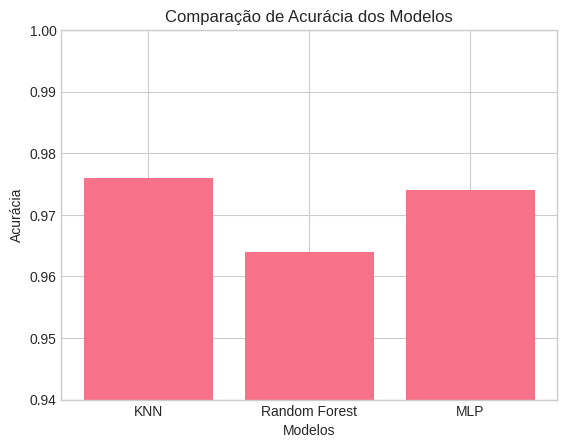

In [ ]:
dados = {
    "Modelo": ["KNN", "Random Forest", "MLP"],
    "Acurácia": [0.976, 0.964, 0.974],
    "Ponto Forte": [
        "Alta precisão em dados semelhantes",
        "Robusto e estável",
        "Aprende padrões complexos"
    ],
    "Ponto Fraco": [
        "Pode ser lento com muitos dados",
        "Menos eficiente para imagens",
        "Depende da arquitetura"
    ]
}

tabela = pd.DataFrame(dados)
display(tabela)

plt.figure()
plt.bar(tabela["Modelo"], tabela["Acurácia"])
plt.title("Comparação de Acurácia dos Modelos")
plt.xlabel("Modelos")
plt.ylabel("Acurácia")
plt.ylim(0.94, 1.0)
plt.show()

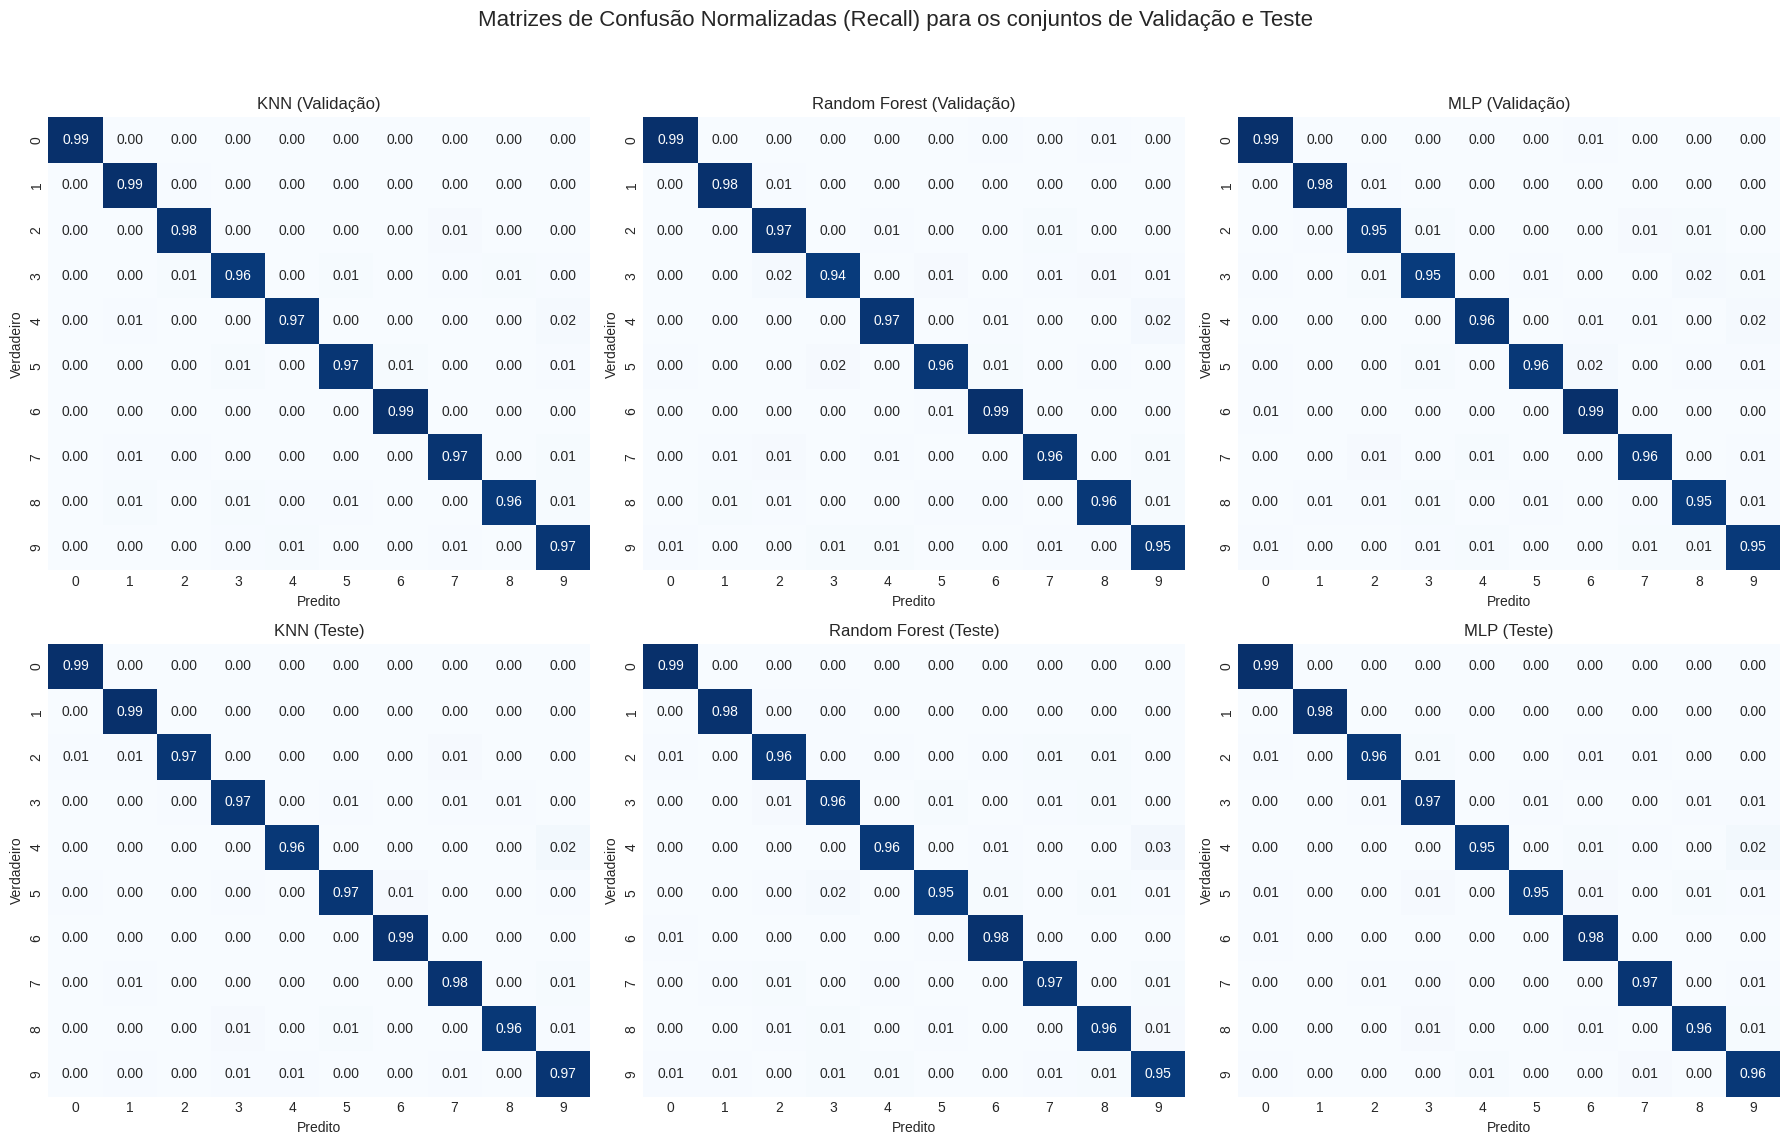

In [ ]:
def plot_normalized_confusion_matrix(y_true, y_pred, ax, title):
    cm = confusion_matrix(y_true, y_pred)
    # Normalize by recall (sum of each row)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(title)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Verdadeiro')
y_pred_val_knn = knn.predict(X_val_pca)
y_pred_val_rf = rf.predict(X_val)
y_pred_val_mlp = mlp.predict(X_val_pca)

# Set up the figure and axes for 2 rows and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Matrizes de Confusão Normalizadas (Recall) para os conjuntos de Validação e Teste', fontsize=16)
plot_normalized_confusion_matrix(y_val, y_pred_val_knn, axes[0, 0], 'KNN (Validação)')
plot_normalized_confusion_matrix(y_val, y_pred_val_rf, axes[0, 1], 'Random Forest (Validação)')
plot_normalized_confusion_matrix(y_val, y_pred_val_mlp, axes[0, 2], 'MLP (Validação)')
plot_normalized_confusion_matrix(y_test, y_pred, axes[1, 0], 'KNN (Teste)')
plot_normalized_confusion_matrix(y_test, y_pred_rf, axes[1, 1], 'Random Forest (Teste)')
plot_normalized_confusion_matrix(y_test, y_pred_mlp, axes[1, 2], 'MLP (Teste)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Top 10 classificações erradas mais comuns (Verdadeiro -> Predito) e quantas vezes ocorrem:
  4 -> 9: 34 ocorrências
  2 -> 7: 18 ocorrências
  5 -> 6: 16 ocorrências
  8 -> 3: 16 ocorrências
  7 -> 9: 13 ocorrências
  3 -> 5: 11 ocorrências
  3 -> 7: 11 ocorrências
  8 -> 5: 11 ocorrências
  9 -> 4: 10 ocorrências
  9 -> 7: 10 ocorrências


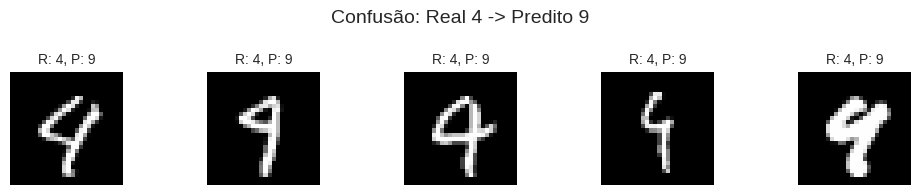

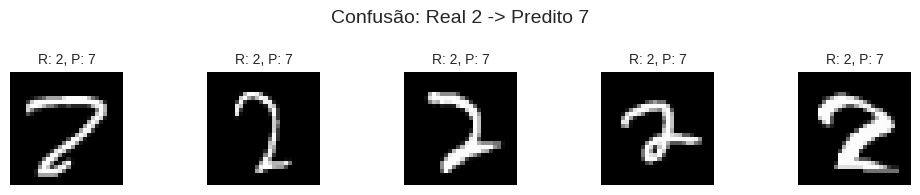

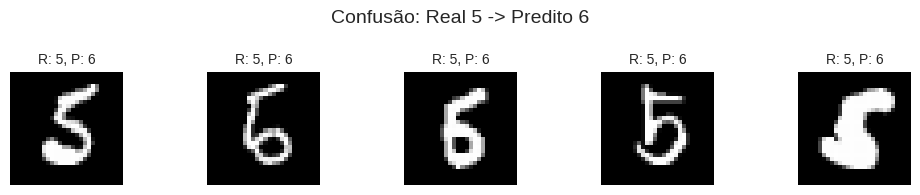

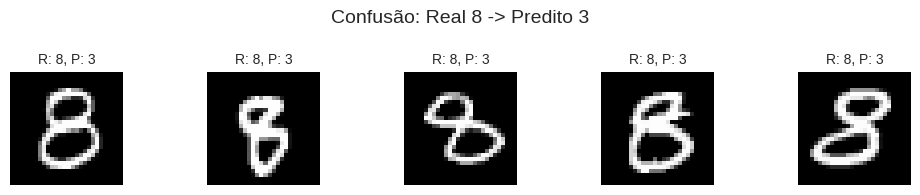

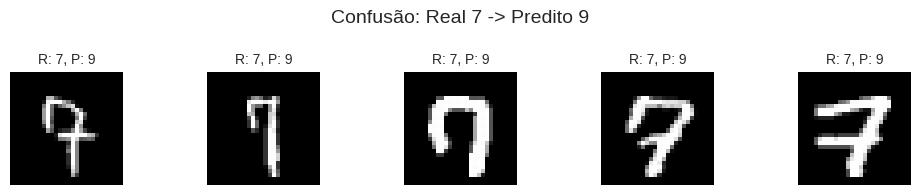

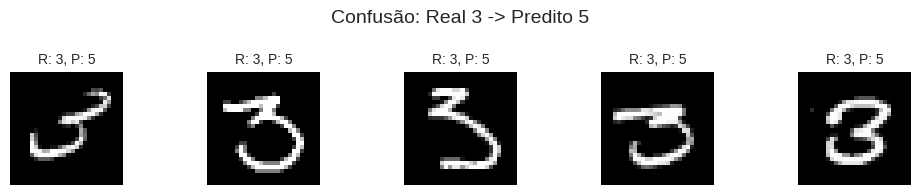

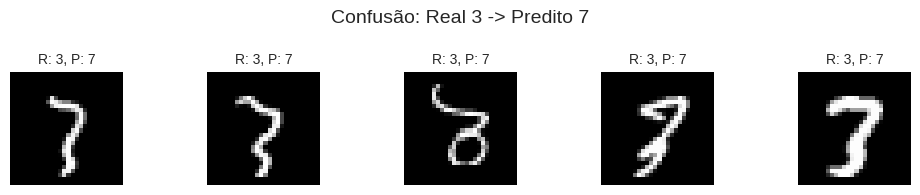

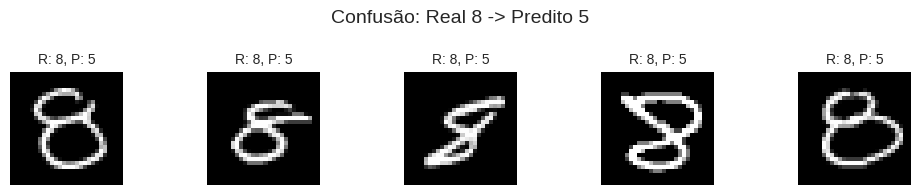

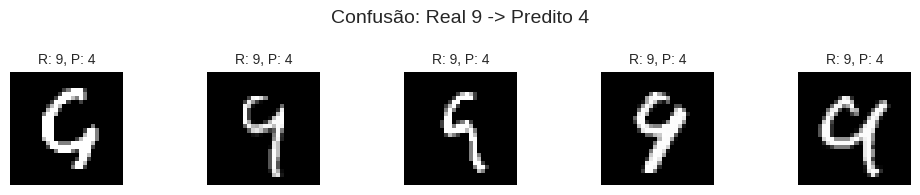

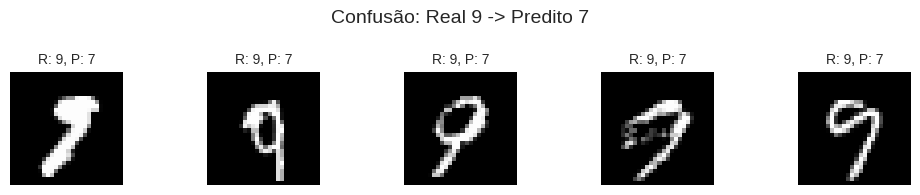

In [ ]:
misclassified_indices = np.where(y_test != y_pred)[0]

confusion_counts = {}

confusion_examples = {}

for idx in misclassified_indices:
    true_label = y_test[idx]
    predicted_label = y_pred[idx]
    pair = (true_label, predicted_label)

    confusion_counts[pair] = confusion_counts.get(pair, 0) + 1

    if pair not in confusion_examples:
        confusion_examples[pair] = []
    confusion_examples[pair].append(idx)

sorted_confusions = sorted(confusion_counts.items(), key=lambda item: item[1], reverse=True)

print("Top 10 classificações erradas mais comuns (Verdadeiro -> Predito) e quantas vezes ocorrem:")
for i, ((true, pred), count) in enumerate(sorted_confusions[:10]):
    print(f"  {true} -> {pred}: {count} ocorrências")

fig_count = 0
for (true_label, predicted_label), _ in sorted_confusions[:10]:
    example_indices = confusion_examples[(true_label, predicted_label)][:5]

    if len(example_indices) > 0:
        fig, axes = plt.subplots(1, len(example_indices), figsize=(2 * len(example_indices), 2))
        fig.suptitle(f'Confusão: Real {true_label} -> Predito {predicted_label}', fontsize=14)

        if len(example_indices) == 1:
            axes = [axes]

        for i, idx in enumerate(example_indices):
            normalized_image = X_test[idx].reshape(28, 28)
            image_for_display = (normalized_image * 0.5) + 0.5
            axes[i].imshow(image_for_display, cmap='gray')
            axes[i].set_title(f'R: {y_test[idx]}, P: {y_pred[idx]}', fontsize=10)
            axes[i].axis('off')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
        fig_count += 1

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

def get_classification_metrics_per_digit(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, output_dict=True)
    metrics_data = []
    for digit in range(10):
        digit_str = str(digit)
        if digit_str in report:
            metrics_data.append({
                'Modelo': model_name,
                'Dígito': digit,
                'Precisão': report[digit_str]['precision'],
                'Recall': report[digit_str]['recall'],
                'F1-Score': report[digit_str]['f1-score'],
                'Suporte': report[digit_str]['support']
            })
    return pd.DataFrame(metrics_data)

knn_metrics_df = get_classification_metrics_per_digit(y_test, y_pred, 'KNN')

rf_metrics_df = get_classification_metrics_per_digit(y_test, y_pred_rf, 'Random Forest')

mlp_metrics_df = get_classification_metrics_per_digit(y_test, y_pred_mlp, 'MLP')

final_report_df = pd.concat([knn_metrics_df, rf_metrics_df, mlp_metrics_df])

print("--- Relatório Final de Métricas por Dígito ---")
display(final_report_df)

--- Relatório Final de Métricas por Dígito ---


,Modelo,Dígito,Precisão,Recall,F1-Score,Suporte
0,KNN,0,0.982117,0.994207,0.988125,1381.0
1,KNN,1,0.976280,0.993016,0.984577,1575.0
2,KNN,2,0.986142,0.967096,0.976526,1398.0
3,KNN,3,0.975300,0.967787,0.971529,1428.0
4,KNN,4,0.987970,0.962637,0.975139,1365.0
5,KNN,5,0.976057,0.968329,0.972178,1263.0
6,KNN,6,0.974892,0.988364,0.981582,1375.0
7,KNN,7,0.966914,0.981494,0.974150,1459.0
8,KNN,8,0.983508,0.961172,0.972212,1365.0
9,KNN,9,0.952113,0.971963,0.961935,1391.0


In [ ]:
import json
import os
import joblib
joblib.dump(knn, "knn_model.pkl", compress=3)
joblib.dump(pca,"pca.pkl")
print("modelos exportados com sucesso")

modelos exportados com sucesso
